In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv(
    "../data/customer_clv.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment,clv
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115,2,Active Customers,44.708219
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118,2,Active Customers,8.790192
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541,0,Inactive Customers,127.794575
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325,0,Inactive Customers,38.839726
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292,0,Inactive Customers,157.512000


In [3]:
df["recency_days"].describe()

count    95419.000000
mean       242.595406
std        153.153422
min          0.000000
25%        118.000000
50%        223.000000
75%        352.000000
max        728.000000
Name: recency_days, dtype: float64

In [4]:
churn_threshold = (
    df["recency_days"]
    .quantile(0.75)
)

df["churn"] = (
    df["recency_days"] > churn_threshold
).astype(int)

print(
    f"Churn Threshold: {churn_threshold:.0f} days"
)

Churn Threshold: 352 days


In [5]:
df["churn"].value_counts()

churn
0    71671
1    23748
Name: count, dtype: int64

In [6]:
df[["frequency","recency_days","churn"]].head()

,frequency,recency_days,churn
0,1,115,0
1,1,118,0
2,1,541,1
3,1,325,0
4,1,292,0


In [7]:
df.groupby("churn")[["frequency","recency_days"]].mean()

,frequency,recency_days
churn,,
0,1.036193,171.457996
1,1.027455,457.286719


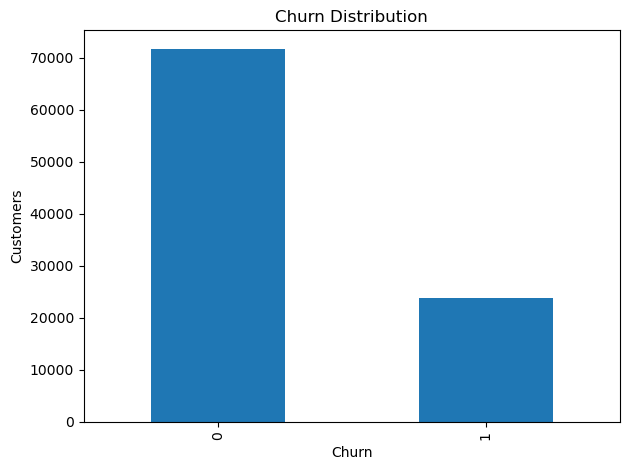

In [8]:
df["churn"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Churn Distribution"
)

plt.xlabel(
    "Churn"
)

plt.ylabel(
    "Customers"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
le = LabelEncoder()

df["customer_segment_encoded"] = le.fit_transform(
    df["customer_segment"]
)

In [10]:
features = [
    "customer_segment_encoded",
    "frequency",
    "monetary",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid"
]

In [11]:
X = df[features]

y = df["churn"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
y_pred = model.predict(
    X_test
)

In [50]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     14334
           1       0.69      0.70      0.69      4750

    accuracy                           0.85     19084
   macro avg       0.79      0.80      0.80     19084
weighted avg       0.85      0.85      0.85     19084



In [81]:
y_prob_rf = model.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print(auc)

0.9187676191315458


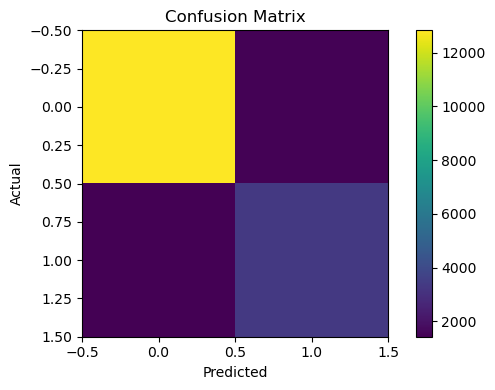

In [53]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
y_prob = model.predict_proba(
    X_test
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

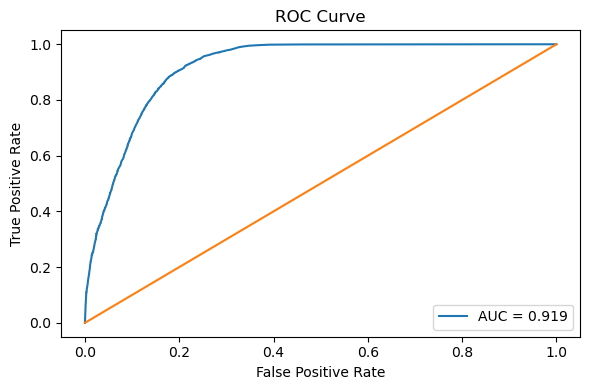

In [55]:
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1]
)

plt.legend()

plt.title(
    "ROC Curve"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [57]:
importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

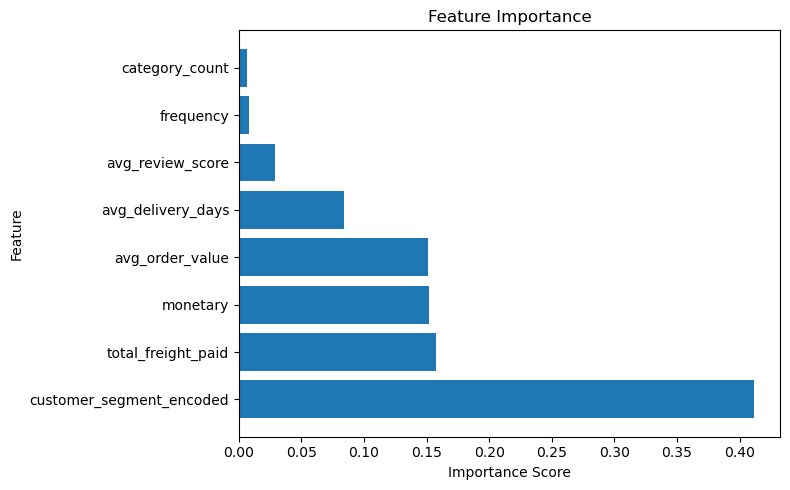

In [58]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
df.to_csv(
    "../data/customer_churn.csv",
    index=False
)

In [60]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [61]:
importance.head(10)

,Feature,Importance
0,customer_segment_encoded,0.411760
7,total_freight_paid,0.157555
2,monetary,0.152143
3,avg_order_value,0.151267
6,avg_delivery_days,0.083672
5,avg_review_score,0.029177
1,frequency,0.007969
4,category_count,0.006456


In [62]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

In [63]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
y_pred_lr = lr.predict(
    X_test
)

y_prob_lr = lr.predict_proba(
    X_test
)[:,1]

In [65]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print(
    "ROC AUC:",
    lr_auc
)

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     14334
           1       0.59      0.91      0.72      4750

    accuracy                           0.82     19084
   macro avg       0.78      0.85      0.80     19084
weighted avg       0.87      0.82      0.83     19084

ROC AUC: 0.8859032113561427


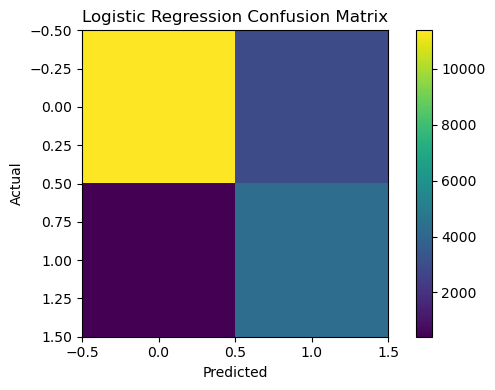

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

plt.imshow(cm)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
from xgboost import XGBClassifier

In [14]:
!pip install xgboost

In [14]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [15]:
xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
import joblib

joblib.dump(
    xgb,
    "../models/churn_xgboost.pkl"
)

['../models/churn_xgboost.pkl']

In [17]:
y_pred_xgb = xgb.predict(
    X_test
)

y_prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.93      0.87      0.90     14334
           1       0.67      0.81      0.73      4750

    accuracy                           0.85     19084
   macro avg       0.80      0.84      0.82     19084
weighted avg       0.87      0.85      0.86     19084



In [19]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "ROC AUC:",
    xgb_auc
)

ROC AUC: 0.9257649240304613


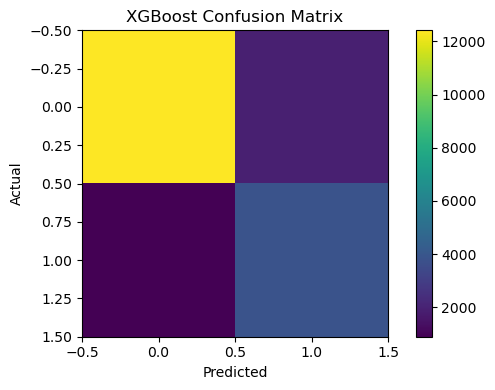

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

plt.imshow(cm)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
0  customer_segment_encoded    0.915096
5          avg_review_score    0.043714
7        total_freight_paid    0.010358
4            category_count    0.008370
6         avg_delivery_days    0.007246
2                  monetary    0.006063
3           avg_order_value    0.005874
1                 frequency    0.003280


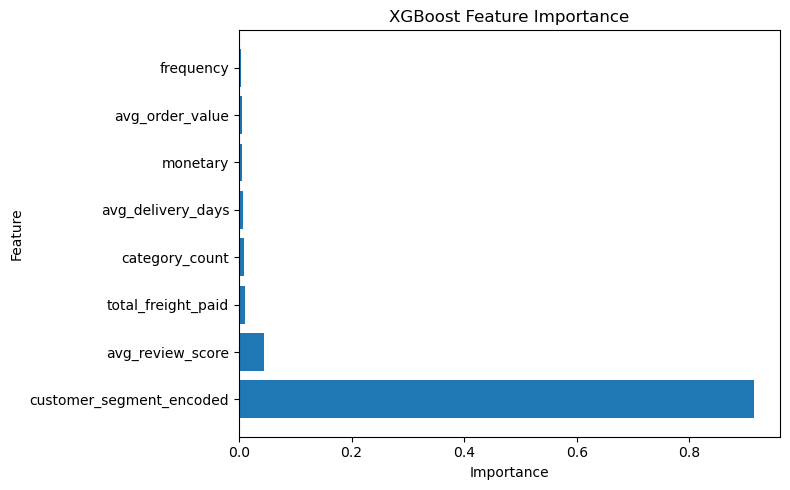

In [22]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/xgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
from sklearn.metrics import roc_curve

fpr_lr,tpr_lr,_ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf,tpr_rf,_ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb,tpr_xgb,_ = roc_curve(
    y_test,
    y_prob_xgb
)

NameError: name 'y_prob_lr' is not defined

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC={lr_auc:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={auc:.3f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost AUC={xgb_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../visualizations/roc_comparison_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
from sklearn.metrics import classification_report

lr_report = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

lr_accuracy = lr_report["accuracy"]

lr_precision = lr_report["1"]["precision"]

lr_recall = lr_report["1"]["recall"]

lr_f1 = lr_report["1"]["f1-score"]

NameError: name 'y_pred_lr' is not defined

In [88]:
rf_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

rf_accuracy = rf_report["accuracy"]

rf_precision = rf_report["1"]["precision"]

rf_recall = rf_report["1"]["recall"]

rf_f1 = rf_report["1"]["f1-score"]

In [89]:
xgb_report = classification_report(
    y_test,
    y_pred_xgb,
    output_dict=True
)

xgb_accuracy = xgb_report["accuracy"]

xgb_precision = xgb_report["1"]["precision"]

xgb_recall = xgb_report["1"]["recall"]

xgb_f1 = xgb_report["1"]["f1-score"]

In [91]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Balanced Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision":[
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall":[
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1":[
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC":[
        lr_auc,
        auc,
        xgb_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.823674,0.594980,0.913263,0.720538,0.885903
1,Balanced Random Forest,0.846206,0.688239,0.698526,0.693344,0.918768
2,XGBoost,0.852442,0.667417,0.811579,0.732472,0.925765


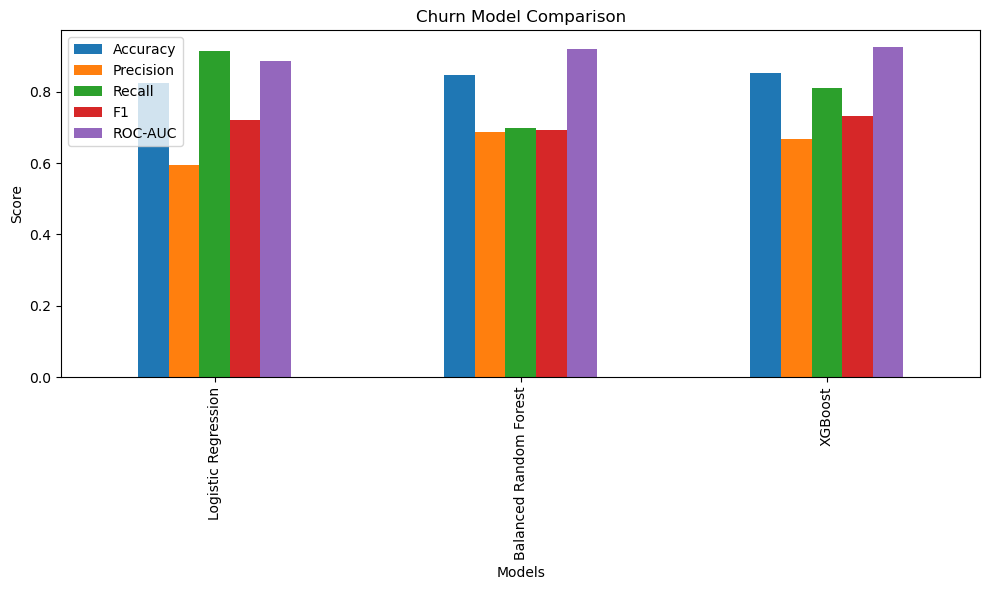

In [92]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Churn Model Comparison"
)

plt.xlabel(
    "Models"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
features = [
    "frequency",
    "monetary",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid"
]

In [94]:
X = df[features]

y = df["churn"]

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [96]:
xgb_ablation= XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [97]:
xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [98]:
y_pred_xgb = xgb.predict(
    X_test
)

y_prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

In [99]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.77      0.99      0.87     14334
           1       0.84      0.11      0.20      4750

    accuracy                           0.77     19084
   macro avg       0.80      0.55      0.53     19084
weighted avg       0.79      0.77      0.70     19084



In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/customer_churn.csv"
)

print(df.columns.tolist())

['frequency', 'monetary', 'avg_order_value', 'category_count', 'avg_review_score', 'avg_delivery_days', 'total_freight_paid', 'recency_days', 'customer_tenure_days', 'cluster', 'customer_segment', 'clv', 'churn', 'customer_segment_encoded']
